In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.model_selection import train_test_split

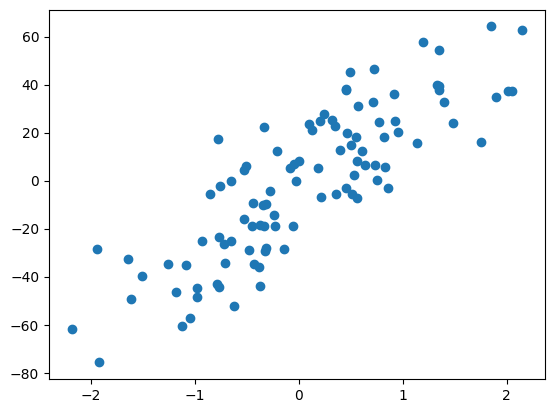

In [4]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

plt.scatter(X, y)



In [5]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)
print(reg.coef_)
print(reg.intercept_)

[27.7413746]
-2.5154637222363108


# visualization with different alpha values

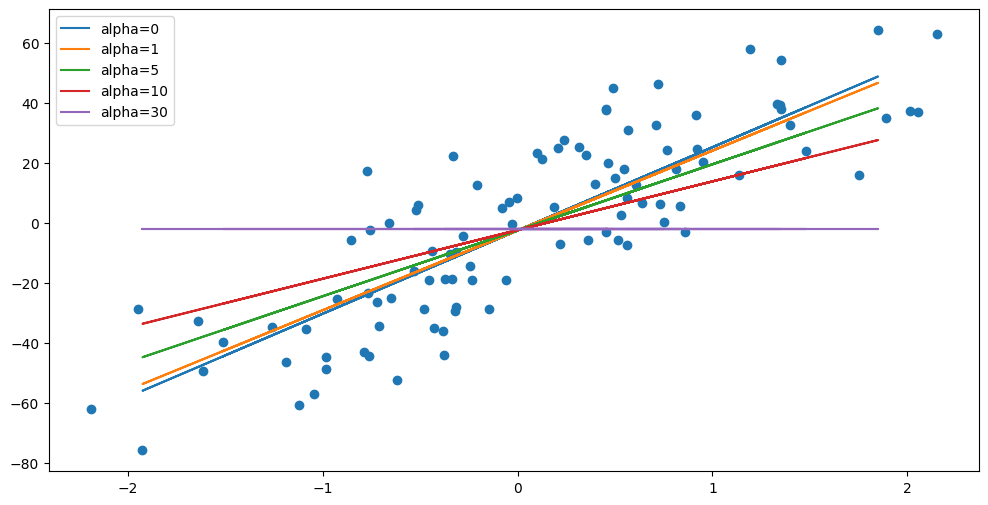

In [10]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    if i == 0:
        model = LinearRegression()
    else:
        model = Lasso(alpha=i, max_iter=10000)
    model.fit(X_train,y_train)
    plt.plot(X_test,model.predict(X_test),label='alpha={}'.format(i))
plt.legend()
plt.show()

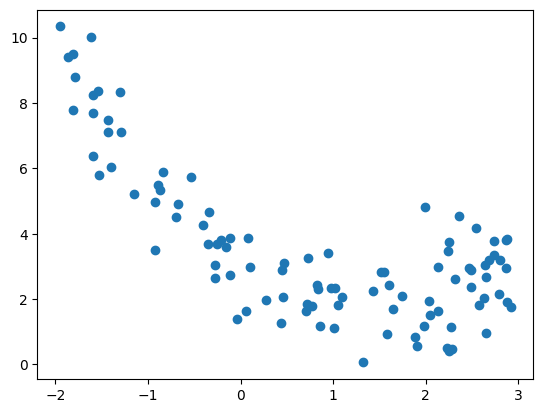

In [7]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

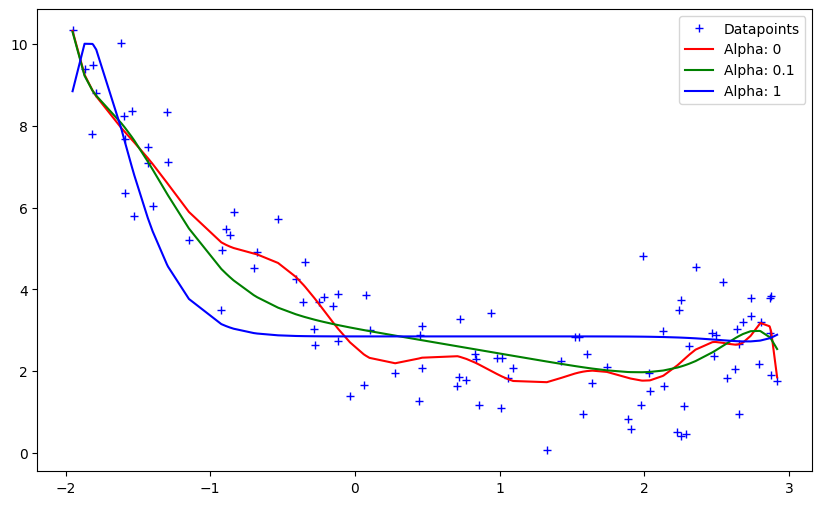

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler # Import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression

def get_preds_lasso(x1, x2, alpha):
    if alpha == 0:
        model_step = ('linear_regression', LinearRegression())
    else:
        model_step = ('lasso', Lasso(alpha=alpha, max_iter=50000)) # Keep max_iter increased

    model = Pipeline([
        ('scaler', StandardScaler()), # Add StandardScaler to the pipeline
        ('poly_feats', PolynomialFeatures(degree=16)),
        model_step
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()